Begin with an image:

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

For implementation we begin with classical gradient flow on $R$. 
We have 
$$
        \text{I}(\rho) = \rho_\text{I}(x,z) = \int_0^1\rho(x,y,z)dy \\
        \text{II}(\rho) = \rho_\text{II}(y,z) = \int_0^1 \rho(x,y,z)dx
$$

$$
        \mathcal{E} = \frac{1}{2}||\text{I}(R)-\rho_\text{I}||_2^2 + \frac{1}{2}||\text{II}(R)-\rho_\text{II}||_2^2 + \text{regularisation}
$$

$$
        R = \arg \min \mathcal{E}
$$

Suppose $R = R[i,j,k]$ is a 3D array.

In [3]:
# image parameters
g = 1
t = 5

# image paths
xz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_xz.png")

yz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_yz.png")

# load images
img_xz = cv2.imread(xz_path, cv2.IMREAD_GRAYSCALE)
img_yz = cv2.imread(yz_path, cv2.IMREAD_GRAYSCALE)

if img_xz is None:
    raise FileNotFoundError(xz_path)

if img_yz is None:
    raise FileNotFoundError(yz_path)

# convert to [0,1]
# rho_xz and rho_yz are the probability distributions along the xz and yz planes
# (x,z) and (y,z) respectively. The .T is to transpose the arrays so that the z-axis is the first axis.
rho_xz = (img_xz > 0).astype(np.float32).T
rho_yz = (img_yz > 0).astype(np.float32).T

# optional denoising / uncertainty model
# rho_xz = cv2.GaussianBlur(rho_xz, (0, 0), sigmaX=2)
# rho_yz = cv2.GaussianBlur(rho_yz, (0, 0), sigmaX=2)

# construct R0
R0 = rho_xz[:, None, :] * rho_yz[None, :, :]

print("rho_xz shape:", rho_xz.shape)
print("rho_yz shape:", rho_yz.shape)
print("R0 shape:", R0.shape)
print("R0 mass:", R0.sum())

rho_xz shape: (512, 512)
rho_yz shape: (512, 512)
R0 shape: (512, 512, 512)
R0 mass: 2083.0


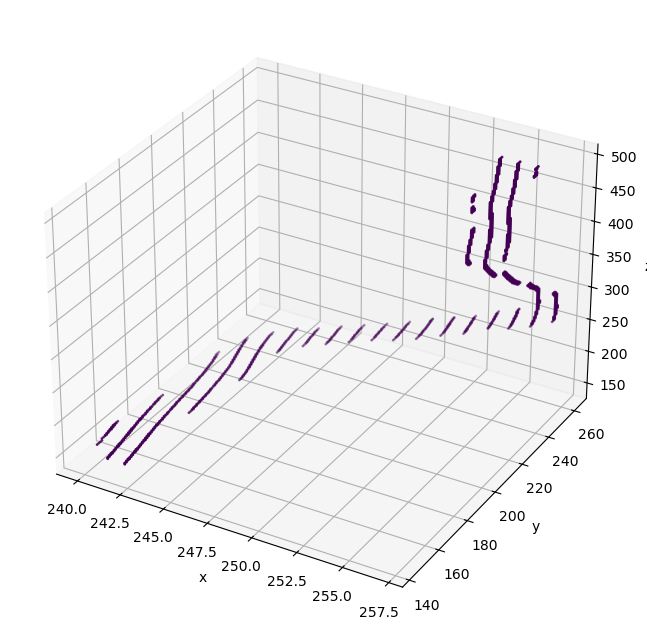

In [4]:
threshold = 0

x, y, z = np.where(R0 > threshold)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=1, c=R0[x,y,z], cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

[np.float32(2188.5), np.float32(1969.0706), np.float32(1771.8049), np.float32(1594.3011), np.float32(1434.682), np.float32(1291.1187), np.float32(1161.9475), np.float32(1045.757), np.float32(941.1693), np.float32(847.10376), np.float32(762.4548), np.float32(686.2584), np.float32(617.70435), np.float32(556.01227), np.float32(500.4853), np.float32(450.49036), np.float32(405.52316), np.float32(365.04944), np.float32(328.60922), np.float32(295.81235), np.float32(266.29205), np.float32(239.72368), np.float32(215.80203), np.float32(194.27405), np.float32(174.9012), np.float32(157.45087), np.float32(141.75743), np.float32(127.6194), np.float32(114.89612), np.float32(103.44303), np.float32(93.13743), np.float32(83.85264), np.float32(75.50215), np.float32(67.97836), np.float32(61.207153), np.float32(55.111633), np.float32(49.629234), np.float32(44.69008), np.float32(40.24362), np.float32(36.24169), np.float32(32.639854), np.float32(29.39674), np.float32(26.478756), np.float32(23.847994), np.flo

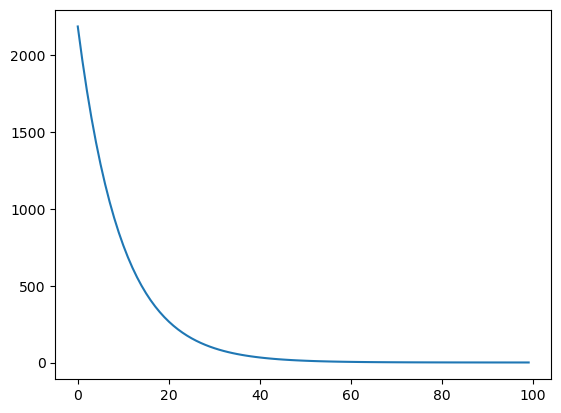

In [5]:
Nx, Ny, Nz = R0.shape
dt = 1e-4
num_steps = 100
Energy = []
R = R0.copy()

for n in range(num_steps):

    # Forward projections
    I_R  = np.sum(R, axis=1)   # integrate over y
    II_R = np.sum(R, axis=0)   # integrate over x

    # Residuals
    e_xz = I_R  - rho_xz
    e_yz = II_R - rho_yz

    # Adjoint operators
    grad_xz = np.repeat(e_xz[:, None, :], Ny, axis=1)

    grad_yz = np.repeat(e_yz[None, :, :], Nx, axis=0)

    # Functional derivative
    grad = grad_xz + grad_yz

    # Gradient flow step
    R -= dt * grad

    E = (0.5 * np.linalg.norm(e_xz)**2 + 0.5 * np.linalg.norm(e_yz)**2)
    Energy.append(E)

plt.plot(Energy)
print(Energy)

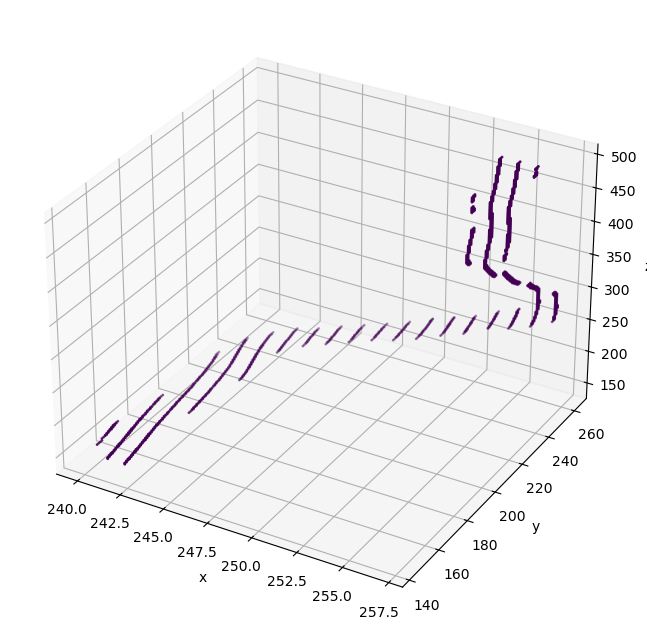

In [6]:
threshold = 0

x, y, z = np.where(R0 > threshold)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=1, c=R0[x,y,z], cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

In [7]:
curve = []

Nx, Ny, Nz = R0.shape
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')

for z in range(Nz):
    P = R0[:, :, z]

    mass = np.sum(P)

    if mass < 1e-12:
        continue

    x = float(np.sum(X * P) / mass)
    y = float(np.sum(Y * P) / mass)

    curve.append([x, y, z])

curve = np.array(curve)

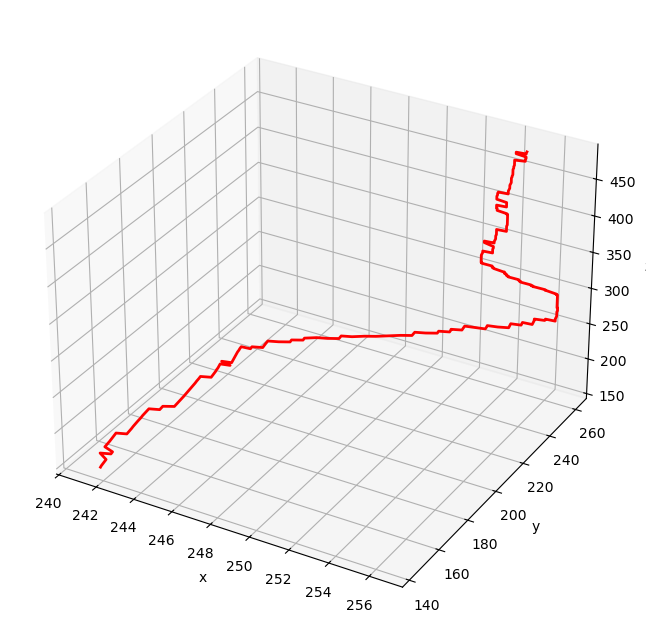

In [8]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    curve[:,0],
    curve[:,1],
    curve[:,2],
    'r-',
    linewidth=2
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

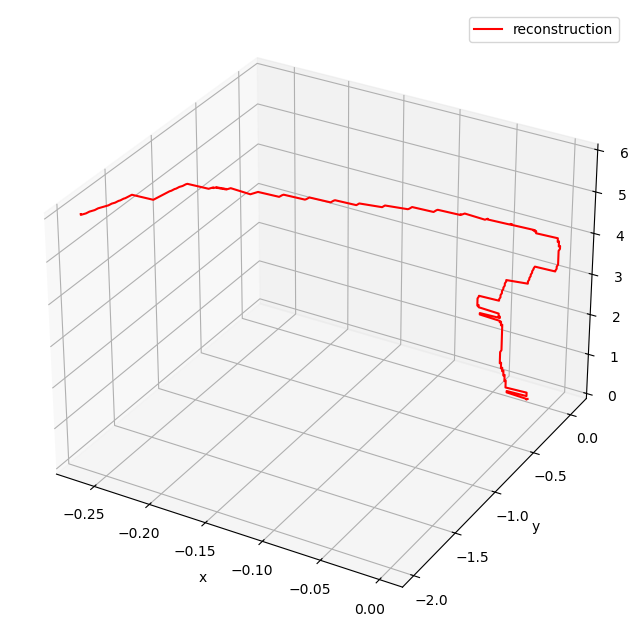

In [12]:
camera_params_path = f"../../data/synthetic/images/gen_{g:02d}/camera_params.csv"

camera_params = pd.read_csv(camera_params_path)

scale = camera_params['scale'].values[0]
x_offset = camera_params['x_offset'].values[0]
z_offset = camera_params['z_offset'].values[0]

Nx, Ny, Nz = R0.shape

x_phys = (np.arange(Nx) - x_offset) / scale
y_phys = (np.arange(Ny) - x_offset) / scale
z_phys = ((Nz - 1) - np.arange(Nz) - z_offset) / scale

curve_phys = np.column_stack([
    x_phys[curve[:,0].astype(int)],
    y_phys[curve[:,1].astype(int)],
    z_phys[curve[:,2].astype(int)]
])


fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    curve_phys[:,0],
    curve_phys[:,1],
    curve_phys[:,2],
    'r-',
    label = "reconstruction"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()

In [ ]:
import pandas as pd

csv_path = f"../../data/synthetic/synthetic_data_independent_views.csv"

df = pd.read_csv(csv_path)

df = df[(df["gen"] == g) & (df["time"] == float(t))]

xz = df[df["view"] == "xz"]
yz = df[df["view"] == "yz"]
print("xz shape:", xz.shape)
print("yz shape:", yz.shape)

xmin, xmax = xz["coord1"].min(), xz["coord1"].max()
ymin, ymax = yz["coord1"].min(), yz["coord1"].max()
zmin, zmax = xz["coord2"].min(), xz["coord2"].max()
print("x range:", xmin, xmax)
print("y range:", ymin, ymax)
print("z range:", zmin, zmax)

xz shape: (200, 6)
yz shape: (200, 6)
x range: -0.49092 0.340455
y range: -0.262363 0.160707
z range: 0.008138 4.341329
